In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("insurance.csv")
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
df["sex"] = df["sex"].map({"female":1,"male":0})
df["smoker"] = df["smoker"].map({"yes":1,"no":0})
df = pd.get_dummies(df, columns=["region"], drop_first=True, dtype=int)

In [5]:
#interaction features
df["bmi_smoker"] = df["bmi"] * df["smoker"]
df["age_smoker"] = df["age"] * df["smoker"]
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_smoker,age_smoker
0,19,1,27.900,0,1,16884.92400,0,0,1,27.90,19
1,18,0,33.770,1,0,1725.55230,0,1,0,0.00,0
2,28,0,33.000,3,0,4449.46200,0,1,0,0.00,0
3,33,0,22.705,0,0,21984.47061,1,0,0,0.00,0
4,32,0,28.880,0,0,3866.85520,1,0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0,0.00,0
1334,18,1,31.920,0,0,2205.98080,0,0,0,0.00,0
1335,18,1,36.850,0,0,1629.83350,0,1,0,0.00,0
1336,21,1,25.800,0,0,2007.94500,0,0,1,0.00,0


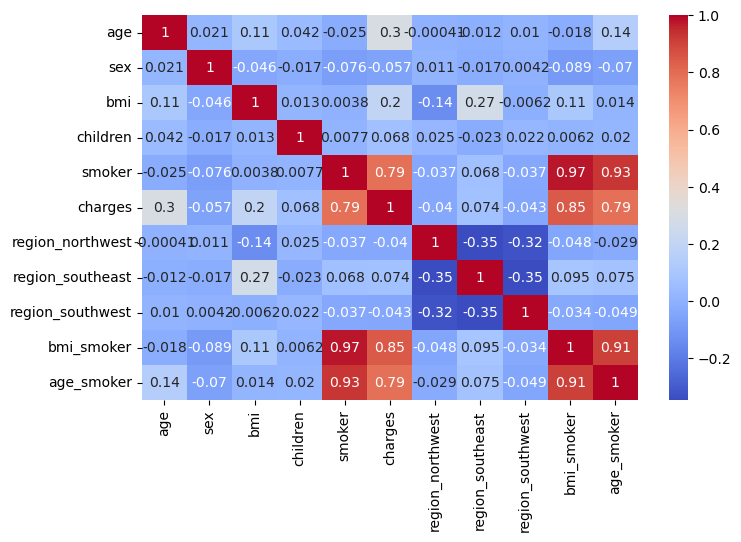

In [6]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [15]:
X = df.drop(columns = ["charges"]) #input
y = df["charges"]      

In [16]:
# Train Test split 
#80% data to train the dataset and 20%data to test the dataset from both x and y (input and output) datasets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,bmi_smoker,age_smoker
560,46,1,19.95,2,0,1,0,0,0.0,0
1285,47,1,24.32,0,0,0,0,0,0.0,0
1142,52,1,24.86,0,0,0,1,0,0.0,0
969,39,1,34.32,5,0,0,1,0,0.0,0
486,54,1,21.47,3,0,1,0,0,0.0,0


In [17]:
# Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred = model.predict(X_test)
y_pred

array([11244.92252985,  7419.09613036, 33108.56263345, 10825.70349972,
       28165.83120369,  6492.30055169,  2795.33432583, 14417.81581562,
        5687.02991028, 11674.71358693, 20657.59012262,  9146.41694187,
        5695.47866425, 51922.27364821, 52110.34418673, 46640.17211168,
       11685.28405314, 43258.65742309, 10134.76643993, 27544.17451838,
        5590.71503071,  9112.26016698,  1829.43896788,  4568.33364842,
       12451.66624573, 12838.44659475, 13233.15939348,  6449.57806469,
       11799.9498717 ,  1825.10642493,  9707.98622109, 12978.53418336,
        3236.11758774,  7025.39527005,  4125.34618621, 10091.32699237,
        3262.60876705,  9119.59871467, 26284.74334712, 37686.43163646,
        4634.27512745,  3702.06635756, 12658.69778308, 12849.08764218,
        6810.63583482, 12752.76878332,  4474.37122331,  5198.08817694,
       41615.58170738,  6338.51473147, 14310.53229154,  2272.59249937,
        9166.71958047,  2711.80386028, 11905.92268657, 12175.67773632,
      

In [19]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [20]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("r-squared:", r2)

r-squared: 0.865231697953168


In [21]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.8340713711218875
Test Score: 0.865231697953168
